In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [4]:
car_data=pd.read_csv("car_dataset.csv")
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df=car_data.copy()

In [6]:
df.shape

(301, 9)

In [7]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [11]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(2)

In [51]:
df = df.drop_duplicates().reset_index(drop=True)

print("New dataset shape:", df.shape)
print("Duplicates after cleaning:", df.duplicated().sum())

New dataset shape: (299, 10)
Duplicates after cleaning: 0


In [52]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [53]:
df['Seller_Type'].value_counts()

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

In [54]:
df['Transmission'].value_counts()

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

In [55]:
df['Owner'].value_counts()

Owner
0    288
1     10
3      1
Name: count, dtype: int64

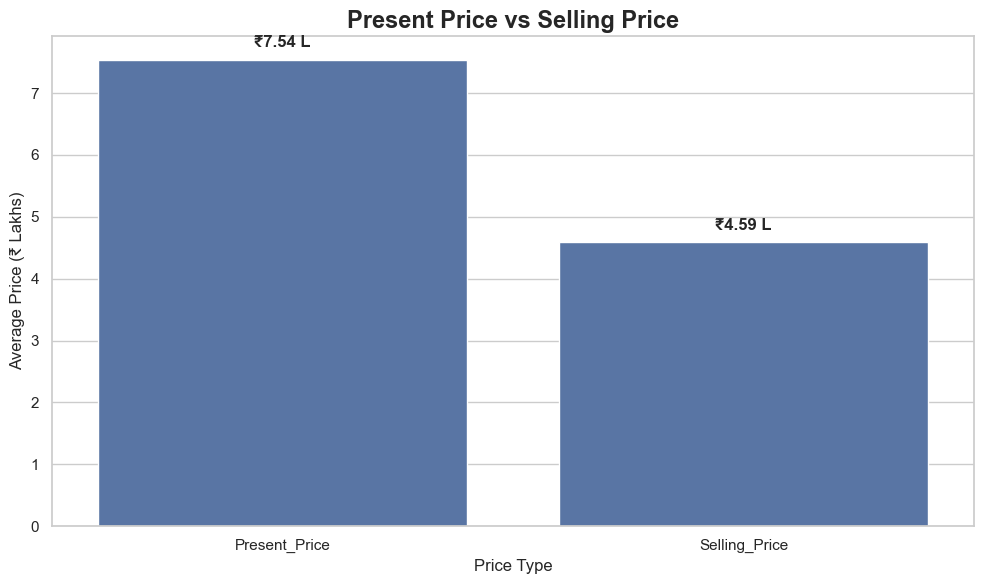

In [56]:
plt.figure(figsize=(10, 6))

average_price = df[["Present_Price", "Selling_Price"]].mean()

ax = sns.barplot(
    x=average_price.index,
    y=average_price.values
)

plt.title(
    "Present Price vs Selling Price",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Price Type", fontsize=12)
plt.ylabel("Average Price (₹ Lakhs)", fontsize=12)

for i, value in enumerate(average_price.values):
    ax.text(
        i,
        value + 0.2,
        f"₹{value:.2f} L",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

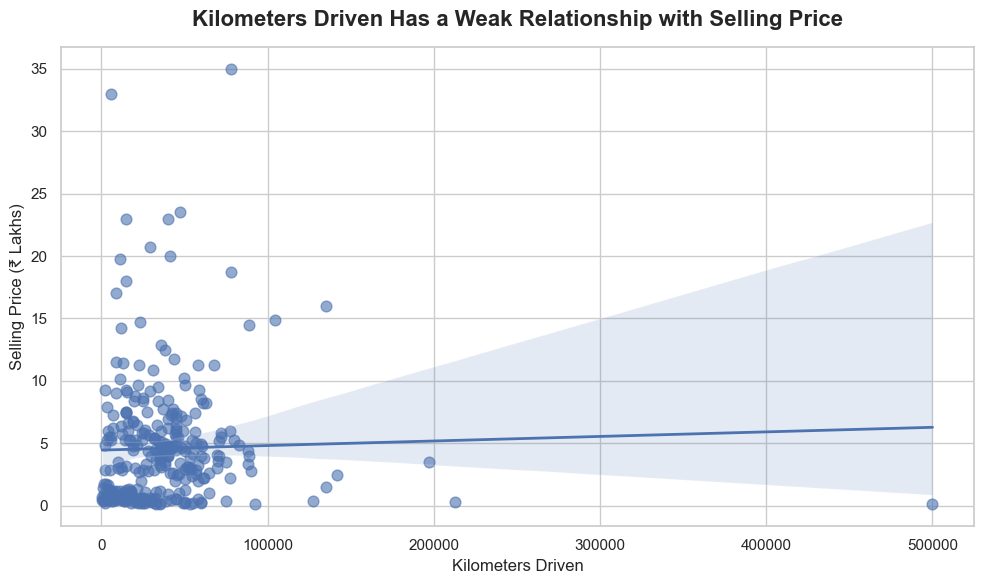

In [57]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price",
    scatter_kws={"s": 60, "alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.title("Kilometers Driven Has a Weak Relationship with Selling Price",
          fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Kilometers Driven", fontsize=12)
plt.ylabel("Selling Price (₹ Lakhs)", fontsize=12)

plt.tight_layout()
plt.show()

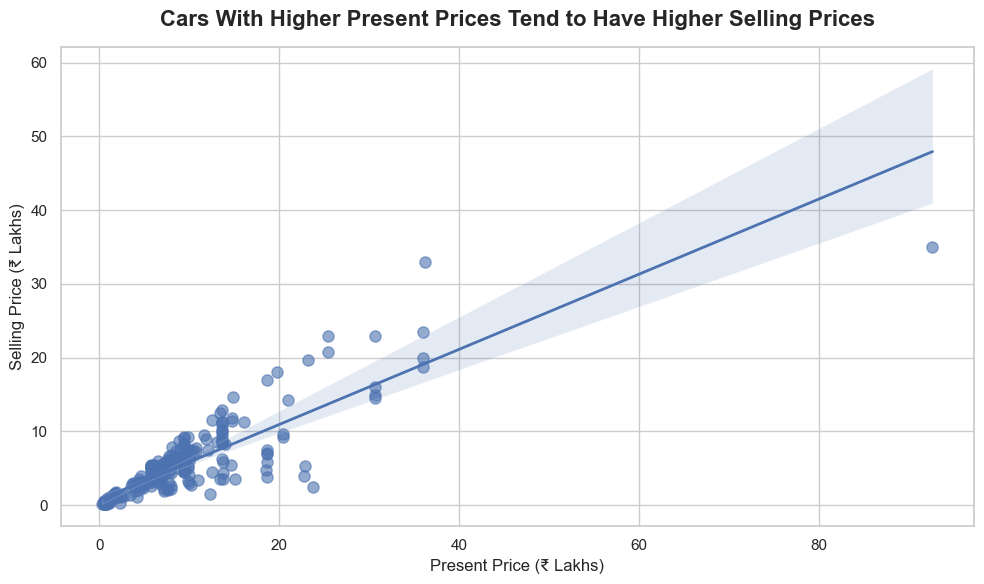

In [58]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Present_Price",
    y="Selling_Price",
    scatter_kws={"s": 65, "alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.title(
    "Cars With Higher Present Prices Tend to Have Higher Selling Prices",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Present Price (₹ Lakhs)", fontsize=12)
plt.ylabel("Selling Price (₹ Lakhs)", fontsize=12)

plt.tight_layout()
plt.show()

In [59]:
df["Price_Difference"] = (
    df["Present_Price"] - df["Selling_Price"]
)

average_difference = df["Price_Difference"].mean()

print(f"Average price difference: ₹{average_difference:.2f} Lakhs")

Average price difference: ₹2.95 Lakhs


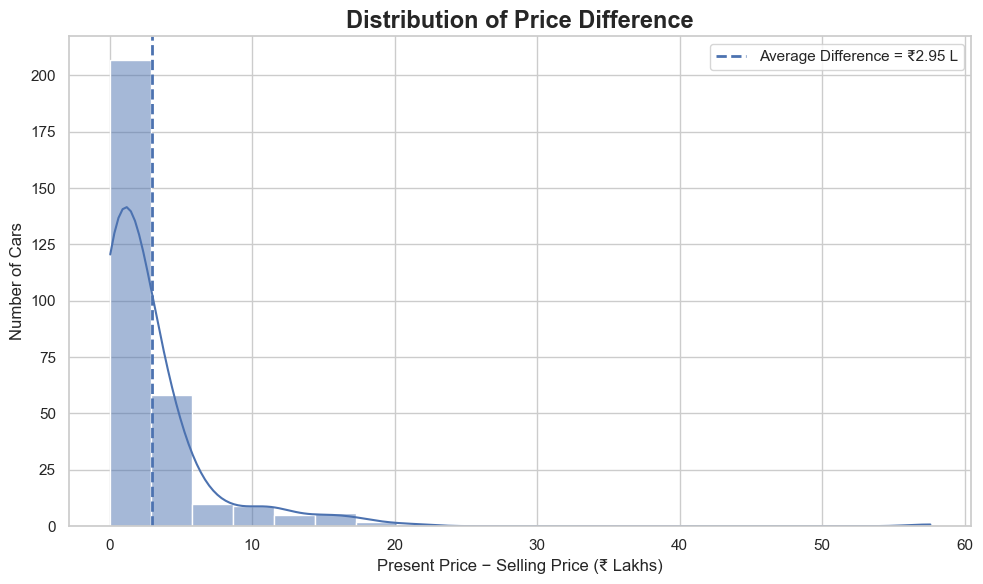

In [60]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Price_Difference"],
    bins=20,
    kde=True
)

plt.axvline(
    average_difference,
    linestyle="--",
    linewidth=2,
    label=f"Average Difference = ₹{average_difference:.2f} L"
)

plt.title(
    "Distribution of Price Difference",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Present Price − Selling Price (₹ Lakhs)", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

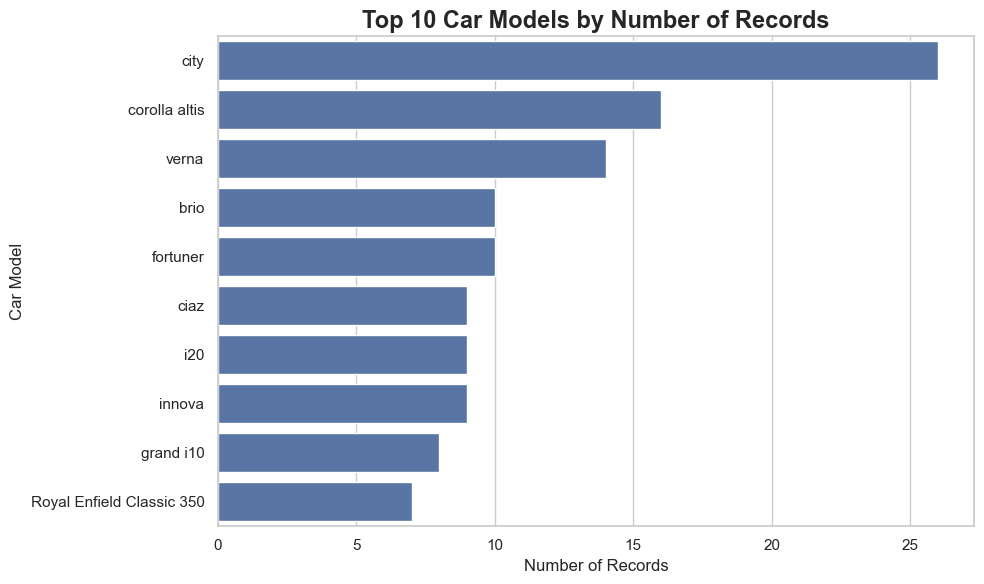

In [61]:
top_cars = df["Car_Name"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_cars.values,
    y=top_cars.index
)

plt.title(
    "Top 10 Car Models by Number of Records",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Records", fontsize=12)
plt.ylabel("Car Model", fontsize=12)

plt.tight_layout()
plt.show()

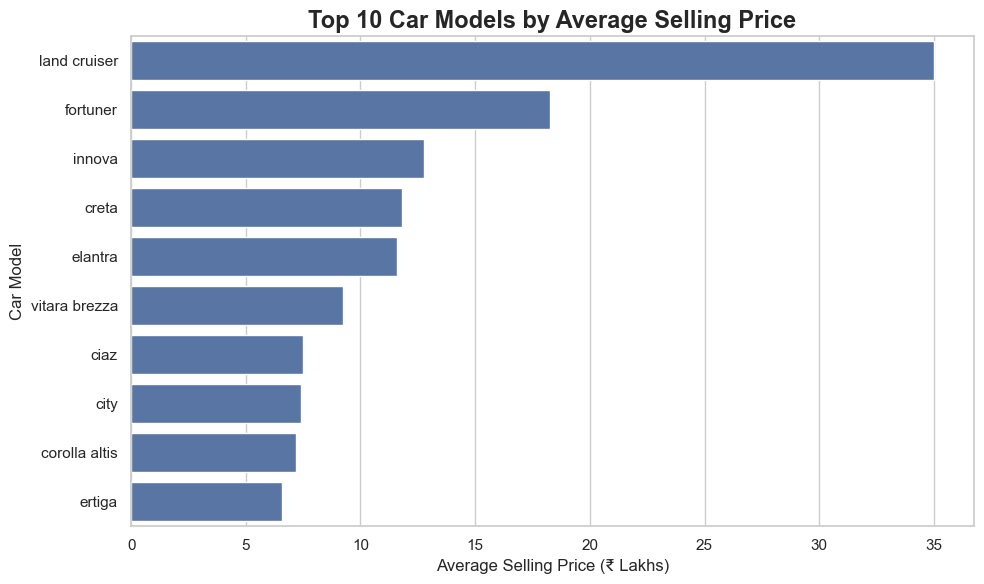

In [62]:
top_price_cars = (
    df.groupby("Car_Name")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_price_cars.values,
    y=top_price_cars.index
)

plt.title(
    "Top 10 Car Models by Average Selling Price",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Average Selling Price (₹ Lakhs)", fontsize=12)
plt.ylabel("Car Model", fontsize=12)

plt.tight_layout()
plt.show()

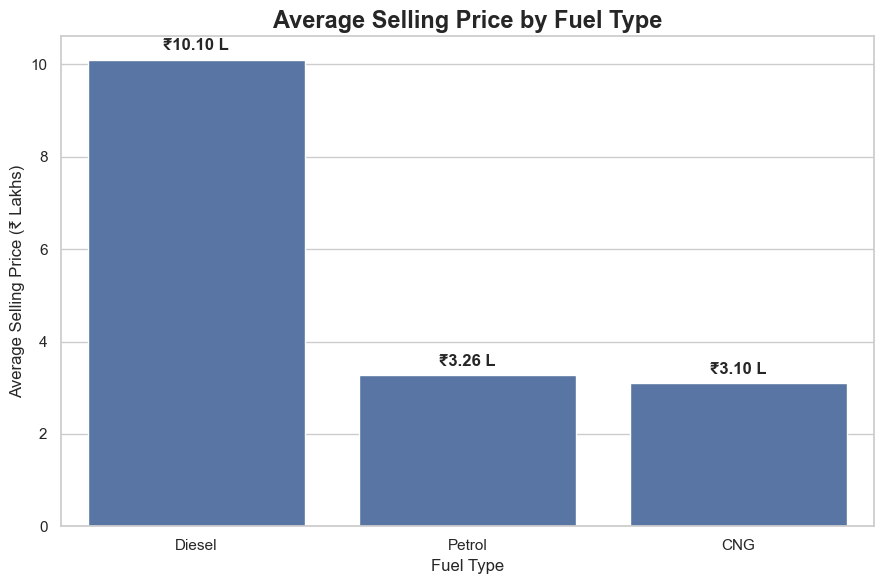

In [63]:
fuel_price = (
    df.groupby("Fuel_Type")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=fuel_price.index,
    y=fuel_price.values
)

plt.title(
    "Average Selling Price by Fuel Type",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Average Selling Price (₹ Lakhs)", fontsize=12)

for i, value in enumerate(fuel_price.values):
    ax.text(
        i,
        value + 0.2,
        f"₹{value:.2f} L",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

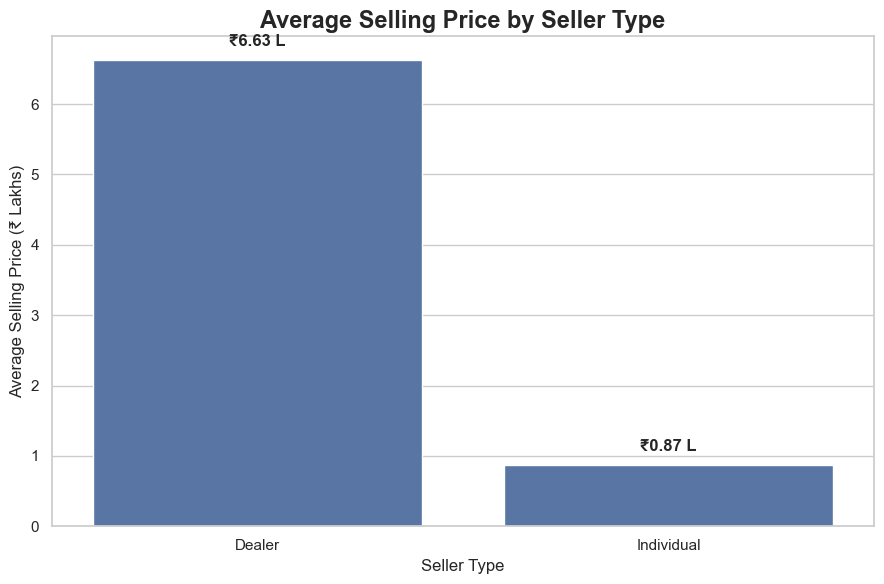

In [64]:
seller_price = (
    df.groupby("Seller_Type")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=seller_price.index,
    y=seller_price.values
)

plt.title(
    "Average Selling Price by Seller Type",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Seller Type", fontsize=12)
plt.ylabel("Average Selling Price (₹ Lakhs)", fontsize=12)

for i, value in enumerate(seller_price.values):
    ax.text(
        i,
        value + 0.2,
        f"₹{value:.2f} L",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

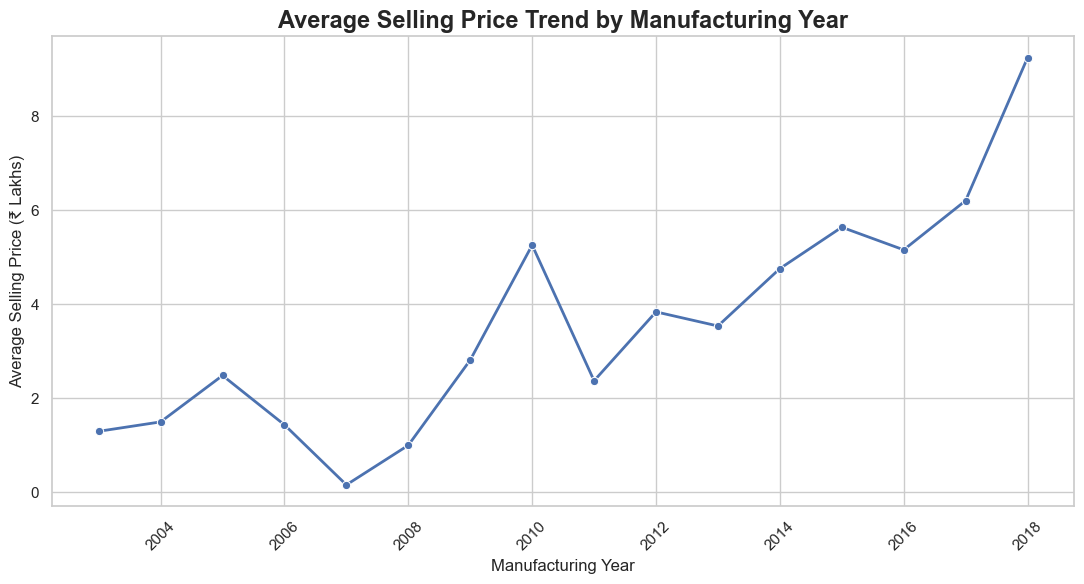

In [65]:
year_price = (
    df.groupby("Year")["Selling_Price"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(11, 6))

sns.lineplot(
    x=year_price.index,
    y=year_price.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Average Selling Price Trend by Manufacturing Year",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Manufacturing Year", fontsize=12)
plt.ylabel("Average Selling Price (₹ Lakhs)", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

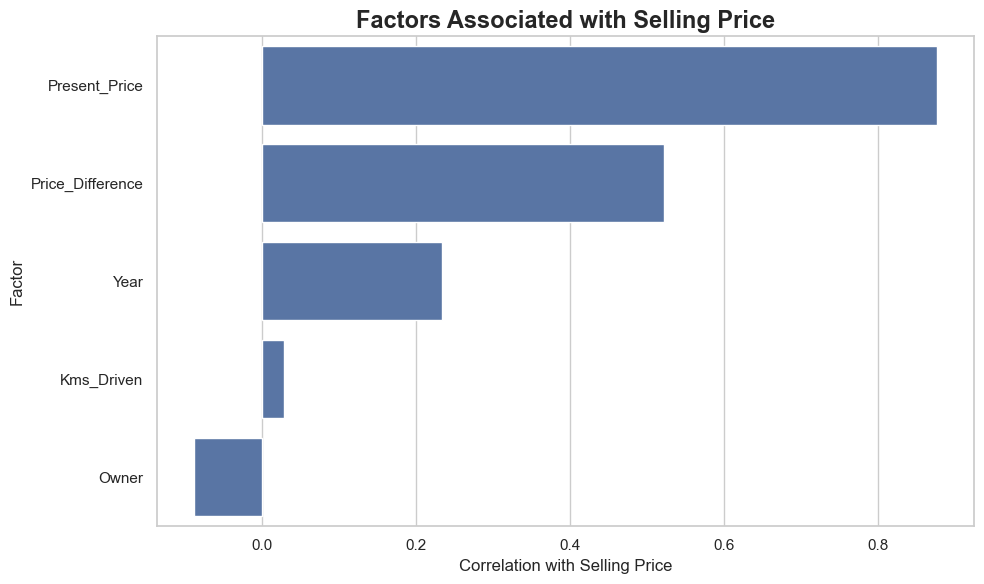

In [66]:
correlation = (
    df.select_dtypes(include="number")
    .corr()["Selling_Price"]
    .drop("Selling_Price")
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=correlation.values,
    y=correlation.index
)

plt.title(
    "Factors Associated with Selling Price",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Correlation with Selling Price", fontsize=12)
plt.ylabel("Factor", fontsize=12)

plt.tight_layout()
plt.show()